In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from re import split
import random

import scipy.integrate as integrate



In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:

def read_txt(file_path):
  if os.path.exists(file_path):
        try:
            with open(file_path, 'r') as f:
                lines = f.readlines()
                data_start_idx = -1

                # Find the line where data starts (after the units line)
                for i, line in enumerate(lines):
                    if '[MeV]    [MeV/c]' in line:
                        data_start_idx = i + 1
                        break

                if data_start_idx != -1:
                    # Join and print only the lines from data_start_idx onwards

                    #content = ''.join(lines[data_start_idx:])
                    #content = lines[data_start_idx:]
                    #print(content)

                    cols = ['E', 'p', 'Ionization', 'Bremsstrahlung', 'Pair Production', 'Photonuclear', 'Radiative Loss', 'dE/dx', 'CSDA Range', 'delta', 'beta', 'dE/dx_R']
                    content={}

                    #Creates a list in which each element is an array containing the lines of the file



                    lines_list=[split(r'\s+', lines[k]) for k in range(data_start_idx, len(lines) )]

                    #Removes first and last entries of the lines_list (that are empty)
                    lines_list=[lines_list[k][1:-1] for k in range(len(lines_list))]

                    #Creates a dictionary with name of columns as keys and content of each column of the dataset as values

                    for i in range(len(cols)):
                        temp=[]
                        for j in range(len(lines_list)):


                            if i>=len(lines_list[j]):
                                temp.append(None)
                                continue

                            if lines_list[j][i]=='Minimum' or  lines_list[j][i]=='Muon' or lines_list[j][i]=='ionization' or lines_list[j][i]=='critical' or lines_list[j][i]=='energy':

                                temp.append(None)
                                continue

                            else:
                                temp.append(float(lines_list[j][i]))
                        #Adding the columns to the dictionary, removing the 1 MeV measurements
                        content[cols[i]] = np.array(temp[1:])

                    #Adding density

                    x=split(r'\s+', split(r',', lines[2])[-1])[3]

                    if x=='$':
                        content['Density'] = float(split(r'\s+', split(r',', lines[2])[-1])[4])/1000

                    else:

                        content['Density'] = float(split(r'\s+', split(r',', lines[2])[-1])[3])

                    #Conversione da keV a MeV?
                    #content['E'] = content['E']/1000


                    return(content)
                else:
                    print(f"Could not determine data start in {file_path}. Printing full content.")
                    print(''.join(lines))

        except Exception as e:
            print(f"Error reading {file_path}: {e}")
  else:
        print(f"\nFile not found: {file_path}")








In [13]:
material = ['Polyvinyltoluene', 'Sodium chloride', 'Aluminum', 'Air' ]

data = {}
for i in range(len(material)):
  data[material[i]] = read_txt(f'/content/drive/MyDrive/Lab Muoni/Documentazione/muE_{material[i].replace(' ', '_')}.txt')

#print(data)


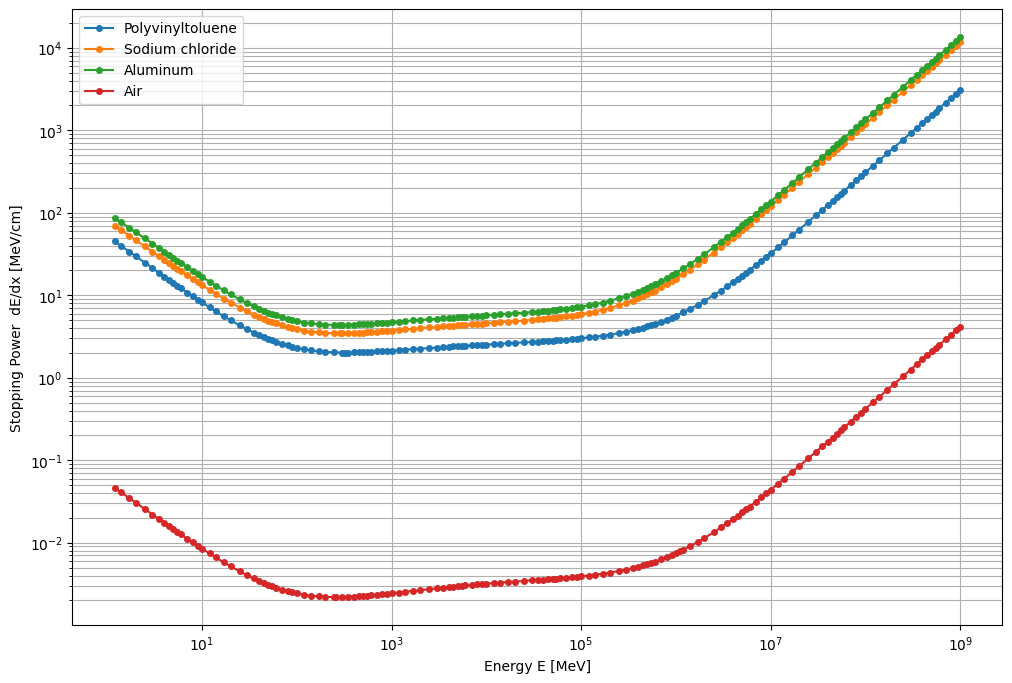

In [14]:
# --- Plotting total Stopping power ---
figure= plt.figure(figsize=(12,8))

for mat in material:

  plt.plot(data[mat]['E'], data[mat]['dE/dx']*data[mat]['Density'],'o-', markersize=4, label=mat)
plt.xscale('log')
plt.yscale('log')


plt.xlabel('Energy E [MeV]')
plt.ylabel('Stopping Power  dE/dx [MeV/cm]')
#plt.title('Stopping Power (dE/dx) vs. Energy (E) for Different Materials')
plt.legend()
plt.grid(True, which="both", ls="-")

plt.savefig('total_StoppingPower.pdf')
plt.show()

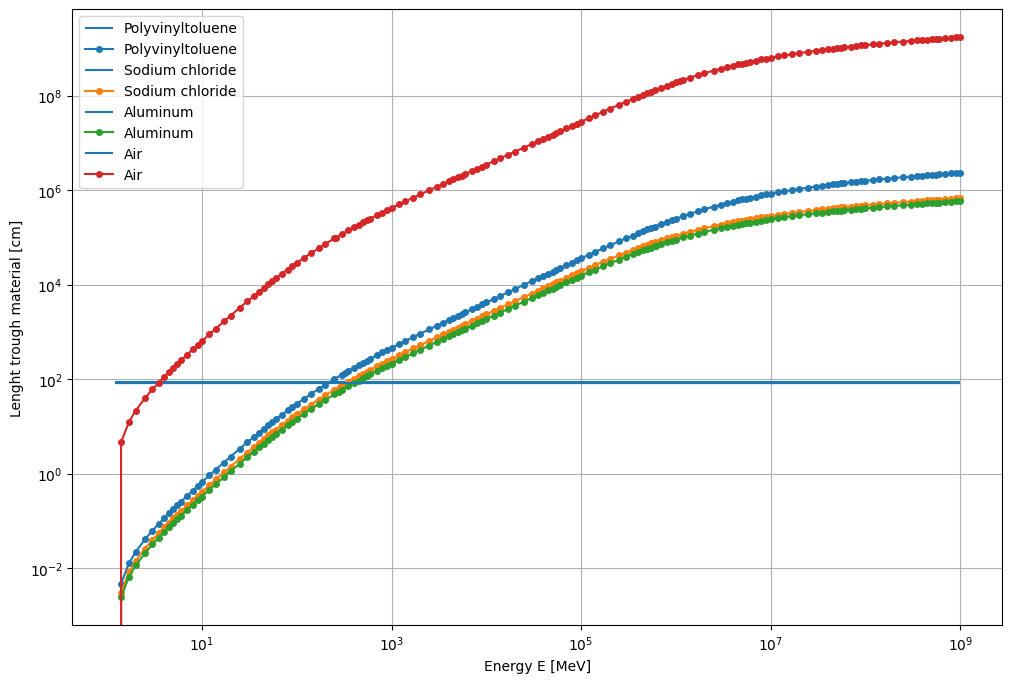

In [15]:
# --- Plotting lenght trough material ---
fig,ax= plt.subplots(figsize=(12,8))

dim_mat={}


dim_mat['Polyvinyltoluene'] = [1, 85.45]
dim_mat['Sodium chloride'] = [6, 85.65]
dim_mat['Aluminum'] = [4, 85.53]
dim_mat['Air'] = [0, 85]
#correggere spessori



for mat in material:
  inv = 1/(data[mat]['dE/dx']*data[mat]['Density'])

  data[mat]['integral'] = integrate.cumulative_trapezoid(inv, data[mat]['E'], initial=0)



for mat in material:
  #plt.fill_between(data[mat]['E'],dim_mat[mat][0], dim_mat[mat][1], alpha=0.25, label=mat)
  plt.hlines(dim_mat[mat][1],min(data[mat]['E']), max(data[mat]['E']), label=mat)

  #plt.plot(data[mat]['E'], 1/(data[mat]['dE/dx']*data[mat]['Density']), label=mat)


  plt.plot(data[mat]['E'], data[mat]['integral'], 'o-', markersize=4, label=mat )

plt.xscale('log')
plt.yscale('log')


plt.xlabel('Energy E [MeV]')
plt.ylabel('Lenght trough material [cm]')
#plt.title('Maximum lenght (dx) vs. Energy (E) for Different Materials')
plt.legend()
plt.grid(True, which="both", ls="-")

plt.savefig('Maximum_lenght.pdf')
plt.show()


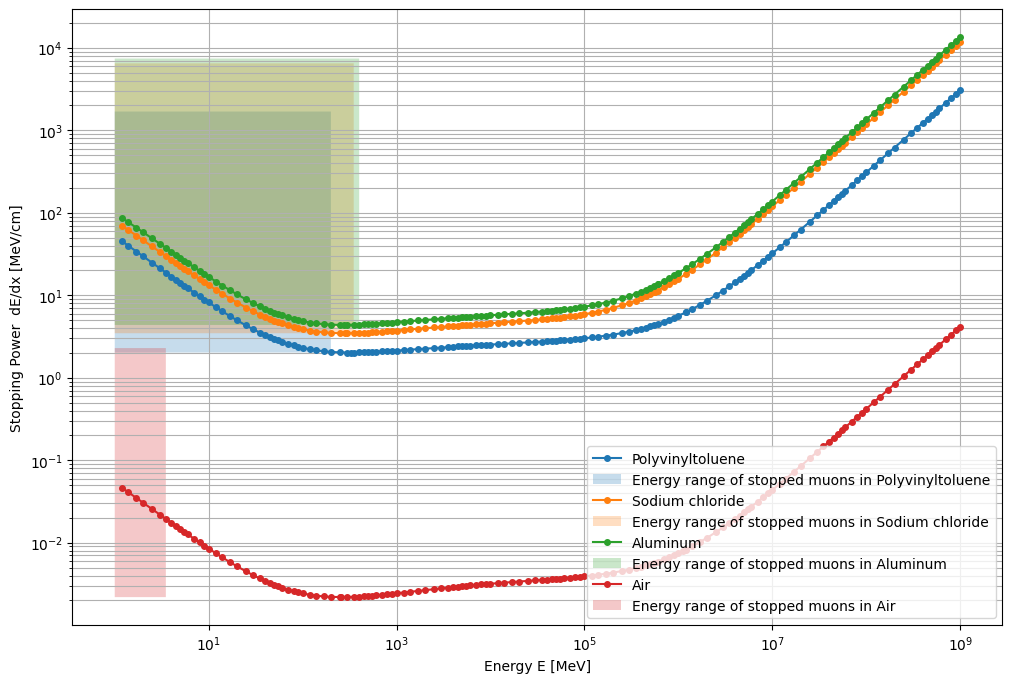

In [16]:
# --- Plotting total Stopping power---
figure= plt.figure(figsize=(12,8))

delta_small = {}
delta_big = {}

E_small = {}
E_big = {}
for mat in material:
  delta_small[mat] = []
  delta_big[mat] = []


  for i,e in enumerate(data[mat]['E']):
    delta_small[mat].append(abs( data[mat]['integral'][i] - dim_mat[mat][0] ))
    delta_big[mat].append(abs( dim_mat[mat][1] - data[mat]['integral'][i] ))

  E_small[mat] = data[mat]['E'][np.argmin(delta_small[mat])]
  E_big[mat] = data[mat]['E'][np.argmin(delta_big[mat])]

  plt.plot(data[mat]['E'], data[mat]['dE/dx']*data[mat]['Density'],'o-', markersize=4, label=mat)


  plt.fill_betweenx(np.linspace( min(data[mat]['dE/dx']*data[mat]['Density']), max( data[mat]['dE/dx'][:-5]*data[mat]['Density'] ), 1000), 1, E_big[mat], alpha=0.25, label='Energy range of stopped muons in '+mat)

plt.xscale('log')
plt.yscale('log')

plt.xlabel('Energy E [MeV]')
plt.ylabel('Stopping Power  dE/dx [MeV/cm]')
#plt.title('Stopping Power (dE/dx) vs. Energy (E) for Different Materials')
plt.legend()
plt.grid(True, which="both", ls="-")

plt.savefig('total_StoppingPower_EnergyRange.pdf')

plt.show()

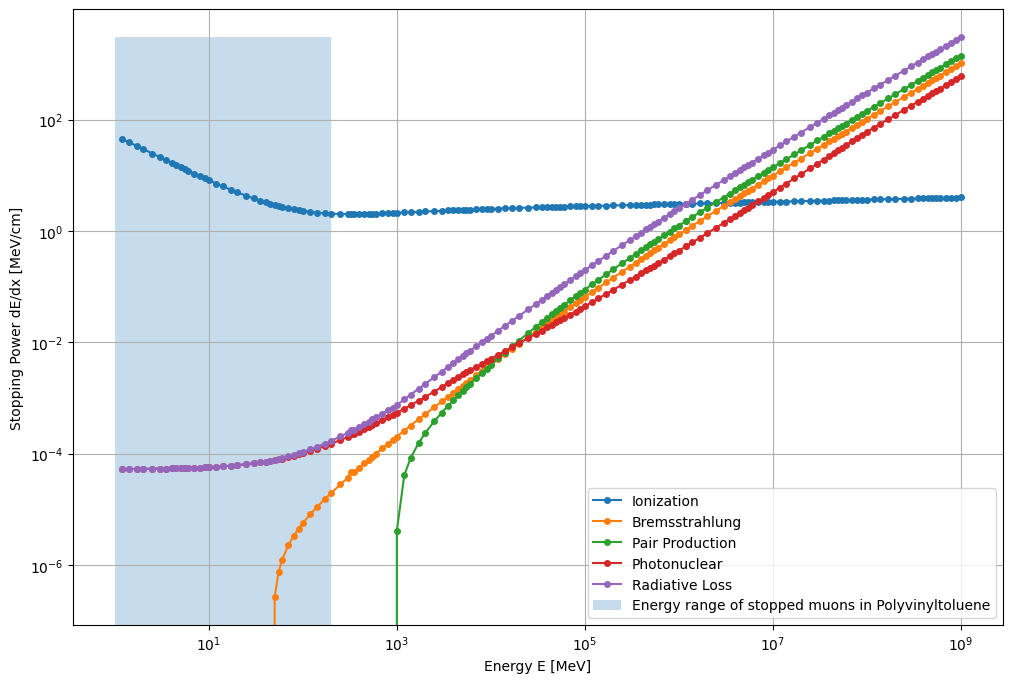

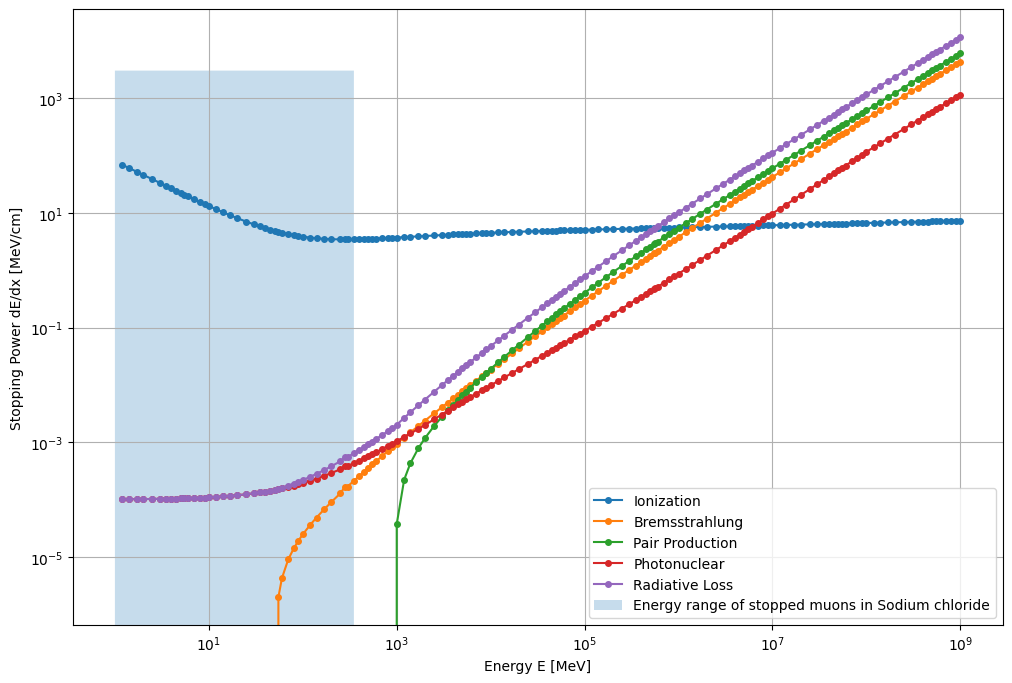

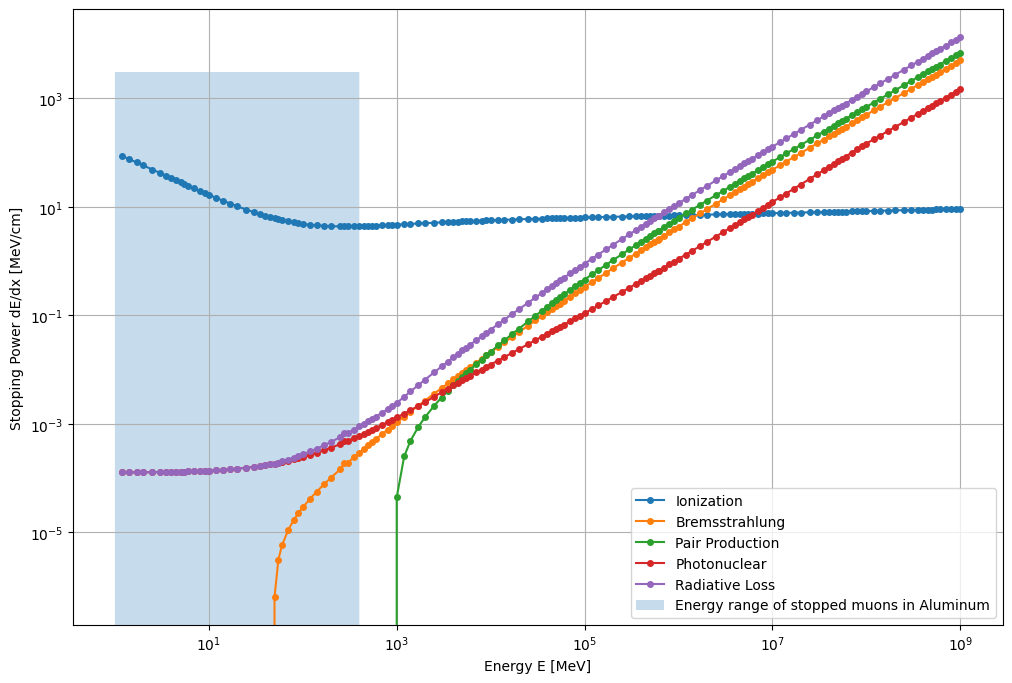

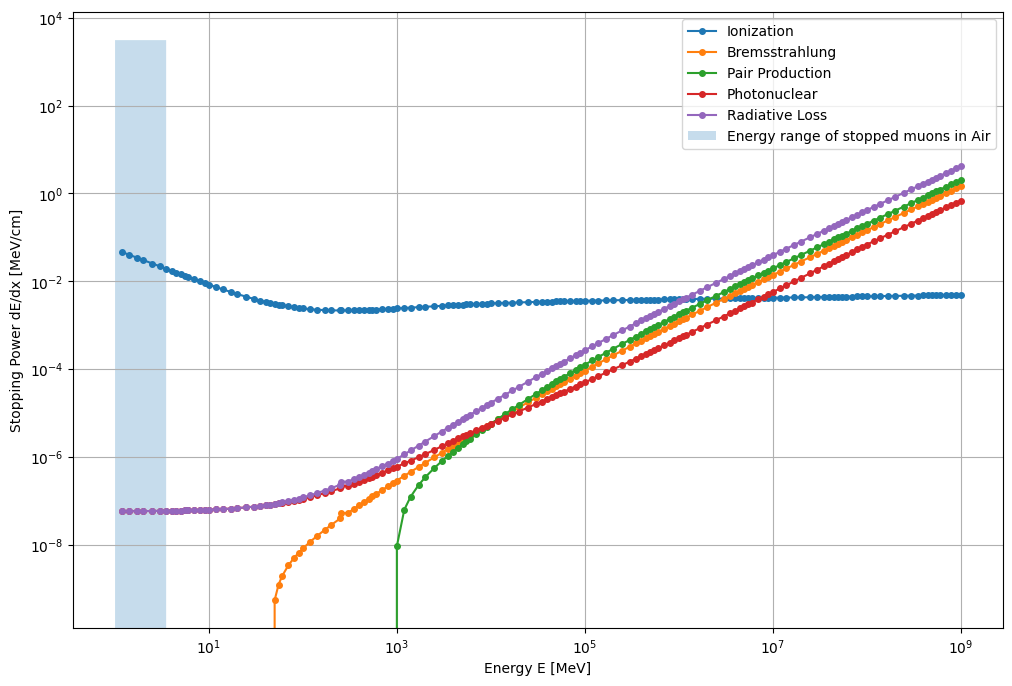

In [17]:
# --- Plotting different Stopping power contributions for each material---

cols = ['E', 'p', 'Ionization', 'Bremsstrahlung', 'Pair Production', 'Photonuclear', 'Radiative Loss', 'dE/dx', 'CSDA Range', 'delta', 'beta', 'dE/dx_R']
for mat in material:
  figure= plt.figure(figsize=(12,8))
  for j in cols[2:7]:
    plt.plot(data[mat]['E'], data[mat][j]*data[mat]['Density'],'o-', markersize=4, label=j)
  plt.fill_betweenx(np.linspace( min(data[mat]['Bremsstrahlung']*data[material[0]]['Density']), max(data[material[0]]['dE/dx']*data[material[0]]['Density']), 1000), 1, E_big[mat], alpha=0.25, label='Energy range of stopped muons in '+mat)

  plt.xscale('log')
  plt.yscale('log')


  plt.xlabel('Energy E [MeV]')
  plt.ylabel('Stopping Power dE/dx [MeV/cm]')
  #plt.title('Different Stopping Power contributions (dE/dx) vs. Energy (E) for '+ mat)
  plt.legend()
  plt.grid(True, which="both", ls="-")

  plt.savefig(f'StoppingPower_contributions_{mat.replace(' ', '_')}.pdf')
  plt.show()

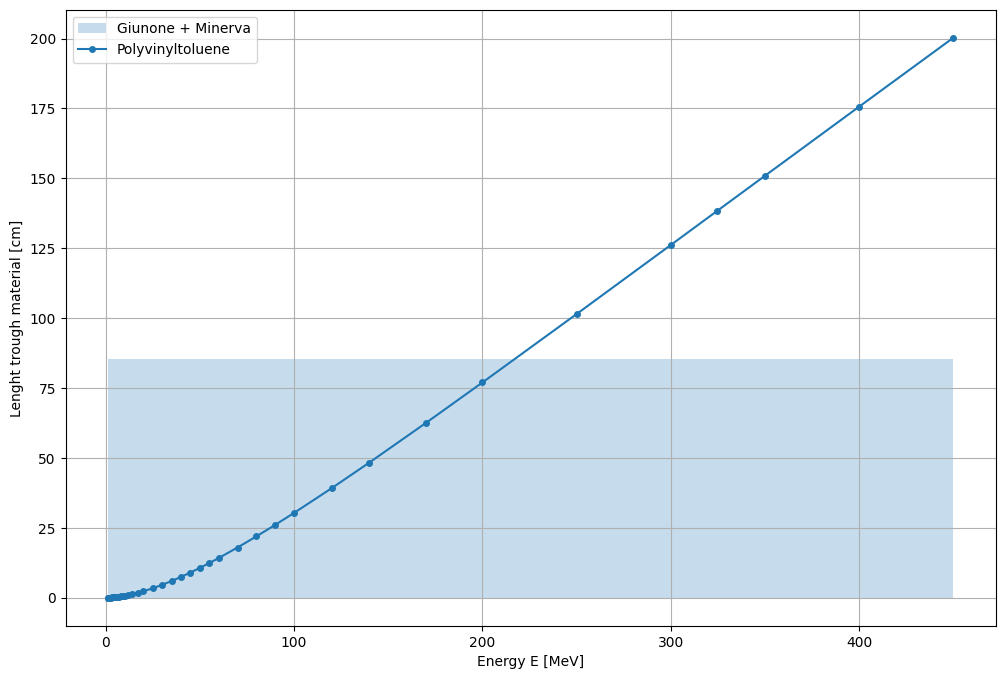

[2.30716537 3.39110275 4.62079624 5.97767974 7.44591351 9.01217662] [20. 25. 30. 35. 40. 45.]


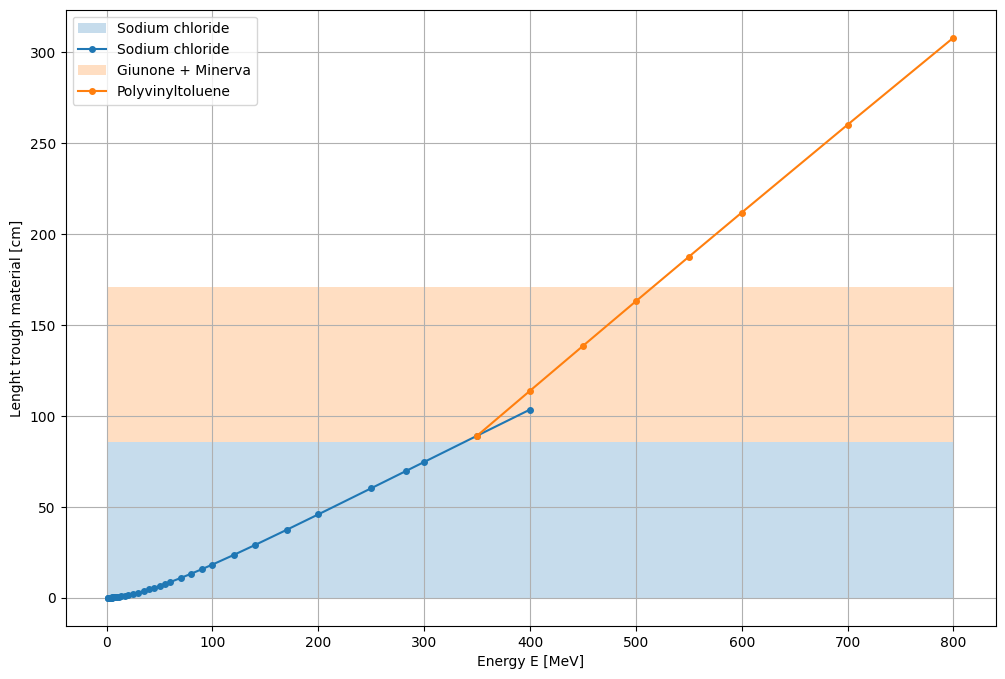

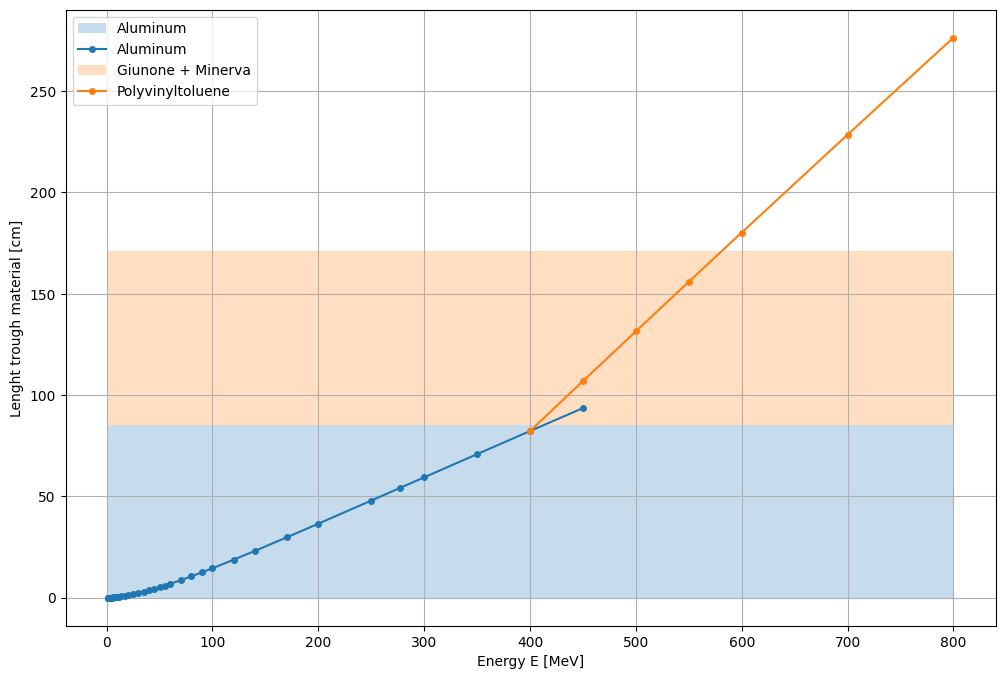

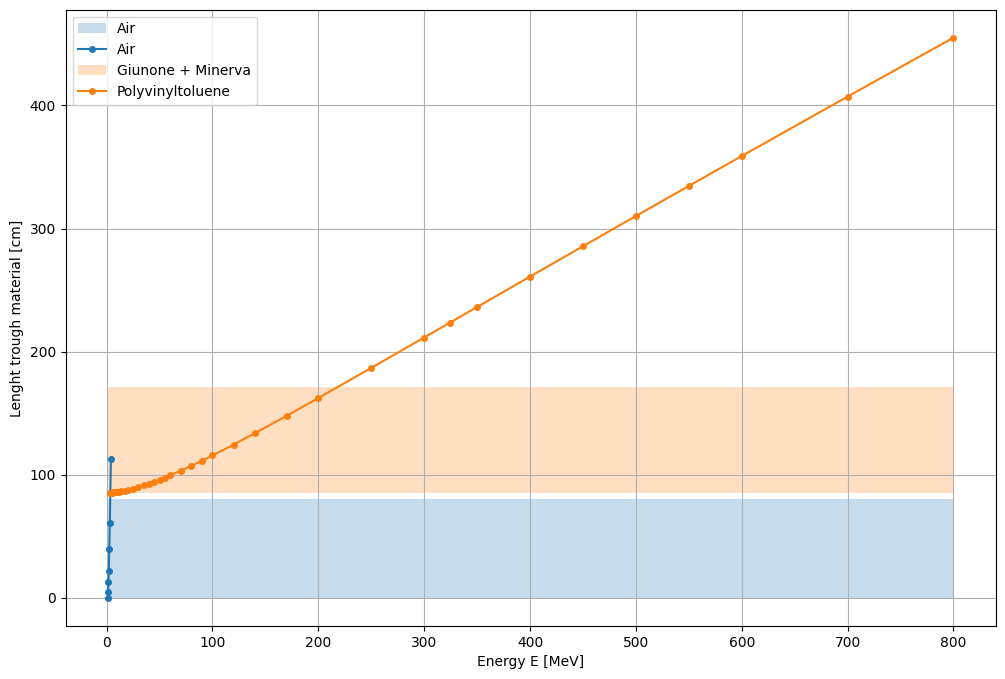

In [9]:
# --- Plotting Stopping power and combinations of material ---
#NOTA: questi grafici fati in questo modo non hanno senso, è necessario integrare in un intervallo specifico di energia, non da 0 ad E
fig,ax= plt.subplots(figsize=(12,8))

interval_plot = 99

range_mat={}


range_mat['Polyvinyltoluene'] = [85.41, 170.9]
range_mat['Sodium chloride'] = [0, 85.41]
range_mat['Aluminum'] = [0, 85.41]
range_mat['Air'] = [0, 80]
#correggere spessori

delta_small = {}
delta_big = {}

E_small = {}
E_big = {}
for mat in material:
  delta_small[mat] = []
  delta_big[mat] = []

  for i,e in enumerate(data[mat]['E']):
    delta_small[mat].append(abs( data[mat]['integral'][i] - range_mat[mat][0] ))
    delta_big[mat].append(abs( range_mat[mat][1] - data[mat]['integral'][i] ))

  E_small[mat] = data[mat]['E'][np.argmin(delta_small[mat])]
  E_big[mat] = data[mat]['E'][np.argmin(delta_big[mat])]


plt.fill_between(data['Polyvinyltoluene']['E'][:np.argmin(delta_big['Polyvinyltoluene'])+2],0, range_mat['Polyvinyltoluene'][1]-range_mat['Polyvinyltoluene'][0], alpha=0.25, label='Giunone + Minerva')


plt.plot(data['Polyvinyltoluene']['E'][:np.argmin(delta_big['Polyvinyltoluene'])+2], data['Polyvinyltoluene']['integral'][:np.argmin(delta_big['Polyvinyltoluene'])+2], 'o-', markersize=4, label='Polyvinyltoluene' )
#plt.xscale('log')
#plt.yscale('log')


plt.xlabel('Energy E [MeV]')
plt.ylabel('Lenght trough material [cm]')
#plt.title('Maximum lenght (dx) vs. Energy (E) for Different Materials')
plt.legend()
plt.grid(True, which="both", ls="-")
plt.show()

print(data['Polyvinyltoluene']['integral'][19:25] , data['Polyvinyltoluene']['E'][19:25])

for mat in material[1:]:

  fig,ax= plt.subplots(figsize=(12,8))

  plt.fill_between(data[mat]['E'][ :-interval_plot],range_mat[mat][0], range_mat[mat][1], alpha=0.25, label=mat)


  plt.plot(data[mat]['E'][ :np.argmin(delta_big[mat])+2 ], data[mat]['integral'][:np.argmin(delta_big[mat])+2], 'o-', markersize=4, label=mat )

  plt.fill_between(data['Polyvinyltoluene']['E'][:-interval_plot],range_mat['Polyvinyltoluene'][0], range_mat['Polyvinyltoluene'][1], alpha=0.25, label='Giunone + Minerva')

  #plt.plot(data[mat]['E'], 1/(data[mat]['dE/dx']*data[mat]['Density']), label=mat)

  plt.plot(data['Polyvinyltoluene']['E'][np.argmin(delta_big[mat]):-interval_plot],
           data['Polyvinyltoluene']['integral'][np.argmin(delta_big[mat]):-interval_plot]
           -data['Polyvinyltoluene']['integral'][np.argmin(delta_big[mat])]
           +data[mat]['integral'][np.argmin(delta_big[mat])], 'o-', markersize=4, label='Polyvinyltoluene' )


  #plt.xscale('log')
  #plt.yscale('log')


  plt.xlabel('Energy E [MeV]')
  plt.ylabel('Lenght trough material [cm]')
  #plt.title('Maximum lenght (dx) vs. Energy (E) for Different Materials')
  plt.legend()
  plt.grid(True, which="both", ls="-")


  plt.show()